# Phase 4 — Exploratory Data Analysis

## NYC Real Estate Price Analysis

### Objective

The goal of this exploratory data analysis (EDA) is to understand the major patterns, relationships, and potential anomalies in the cleaned NYC real estate dataset before moving into feature engineering and machine learning.

This notebook answers four core business questions:

1. **Price Distribution** — How are listing prices distributed, and which property types are more expensive?
2. **Property Size** — Is there a relationship between living area and listing price?
3. **Location** — Where are the properties located, and where are higher-priced properties concentrated?
4. **Market Analysis** — Which ZIP codes have higher prices and how many listings support those comparisons?

> **Important:** Outliers are investigated rather than automatically removed. In real estate, unusually expensive or large properties may represent legitimate luxury or multi-family listings rather than data errors.


## Notebook Workflow

| Analysis | Main Variables | Business Question |
|---|---|---|
| Price Distribution | `listing_price`, `home_type` | Which property types are expensive? Are there luxury outliers? |
| Property Size | `living_area`, `listing_price` | Do larger properties generally sell for more? |
| Location | `latitude`, `longitude`, `listing_price` | Where are properties and higher prices concentrated? |
| Market Analysis | `zip_code`, `listing_price` | Which ZIP codes have the highest average/median prices and listing volume? |

### Visualization Libraries

- **Matplotlib / Seaborn** — statistical charts
- **Plotly** — interactive charts and maps
- **Folium** — interactive geographic heatmaps


## 1. Import Libraries

The notebook uses a small set of standard data-science and visualization libraries. `Path` is used so the dataset path works more reliably in a GitHub repository and can still be adjusted for Google Colab if necessary.


In [1]:
# Import standard-library utilities for file-path handling.
from pathlib import Path

# Import data-manipulation and numerical libraries.
import numpy as np
import pandas as pd

# Import static visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Import interactive visualization libraries.
import plotly.express as px
import folium
from folium.plugins import HeatMap

# Configure pandas to display all columns when inspecting DataFrames.
pd.set_option("display.max_columns", None)

# Apply a consistent visual style across Seaborn charts.
sns.set_theme(style="whitegrid")

# Set a default figure size for Matplotlib/Seaborn visualizations.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


## 2. Load the Final Cleaned Dataset

The EDA uses the final dataset produced during the data-cleaning phase.

Expected project structure:

```text
project/
├── data/
│   └── final_cleaned_zillow.csv
└── notebooks/
    └── 03_EDA.ipynb
```

The fallback path also allows the notebook to run when the CSV is placed in the same working directory, such as in Google Colab.


In [2]:
# Define the expected path when the notebook is stored in a /notebooks directory.
DATA_PATH = Path("../data/final_cleaned_zillow.csv")

# Fall back to the current working directory for environments such as Google Colab.
if not DATA_PATH.exists():
    DATA_PATH = Path("final_cleaned_zillow.csv")

# Stop with a clear message if the dataset cannot be found.
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found. Expected: '../data/final_cleaned_zillow.csv' "
        f"or 'final_cleaned_zillow.csv'. Current working directory: {Path.cwd()}"
    )

# Load the cleaned Zillow dataset into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

# Display the first five records to confirm that the dataset loaded correctly.
df.head()


,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address,property_key,zestimate_missing,tax_assessed_missing,price_per_sqft,price_outlier,price_vs_zestimate,price_zestimate_ratio,rent_missing,tax_missing
0,"572 Louisiana Avenue #1, Brooklyn, NY 11239",11239,2.0,2.0,1017.0,40.647620,-73.886810,250000.0,3550.0,856400.0,CONDO,24,forSale,30775866,570294.0,572 LOUISIANA AVENUE BROOKLYN NY 11239,30775866,0,0,245.821042,0,-606400.0,0.291920,0,0
1,"2183 Ocean Ave #4A, Brooklyn, NY 11229",11229,1.0,1.0,541.0,40.608430,-73.952736,485000.0,2489.0,473800.0,CONDO,16,forSale,463914912,817000.0,2183 OCEAN AVE BROOKLYN NY 11229,463914912,0,1,896.487985,0,11200.0,1.023639,0,0
2,"8885 15th Ave, Brooklyn, NY 11228",11228,4.0,3.0,2060.0,40.605550,-74.015200,1299000.0,5015.0,1315600.0,SINGLE_FAMILY,4,forSale,30714518,1320000.0,8885 15TH AVE BROOKLYN NY 11228,30714518,0,0,630.582524,0,-16600.0,0.987382,0,0
3,"300 Milford St, Brooklyn, NY 11208",11208,3.0,2.0,1232.0,40.671783,-73.876625,595000.0,3574.0,602800.0,SINGLE_FAMILY,29,forSale,30640361,729000.0,300 MILFORD ST BROOKLYN NY 11208,30640361,0,0,482.954545,0,-7800.0,0.987060,0,0
4,"2711 Avenue X Unit F2, Brooklyn, NY 11235",11235,2.0,1.0,1000.0,40.704254,-73.966420,345000.0,3056.0,350500.0,MULTI_FAMILY,20,forSale,463826019,817000.0,2711 AVENUE X UNIT F2 BROOKLYN NY 11235,463826019,0,1,345.000000,0,-5500.0,0.984308,0,0


In [3]:
# Define the columns required for the analyses in this notebook.
required_columns = [
    "listing_price",
    "home_type",
    "living_area",
    "latitude",
    "longitude",
    "zip_code",
]

# Identify any required columns that are missing from the dataset.
missing_required_columns = [
    column for column in required_columns if column not in df.columns
]

# Raise an informative error before any analysis if a required column is missing.
if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

# Report the dataset dimensions after loading the final cleaned data.
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dataset shape: 1,892 rows × 25 columns


## 3. Dataset Overview

Before analyzing individual variables, we verify the structure and quality of the final dataset.

The checks below cover:

- Dataset dimensions
- Data types
- Descriptive statistics
- Missing values
- Duplicate records
- Property-type distribution
- ZIP-code coverage


In [4]:
# Display column names, data types, and non-null counts.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1892 entries, 0 to 1891
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   address                1892 non-null   object 
 1   zip_code               1892 non-null   int64  
 2   bedrooms               1892 non-null   float64
 3   bathrooms              1892 non-null   float64
 4   living_area            1892 non-null   float64
 5   latitude               1892 non-null   float64
 6   longitude              1892 non-null   float64
 7   listing_price          1892 non-null   float64
 8   rent_estimate          1892 non-null   float64
 9   zestimate              1892 non-null   float64
 10  home_type              1892 non-null   object 
 11  days_on_zillow         1892 non-null   int64  
 12  listing_status         1892 non-null   object 
 13  zpid                   1892 non-null   int64  
 14  tax_assessed_value     1892 non-null   float64
 15  clea

In [5]:
# Generate descriptive statistics for numerical and categorical columns.
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
address,1892,1891,"9133 Avenue N, Brooklyn, NY 11236",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,1892.0,NaN,NaN,NaN,11318.199789,197.276979,11001.0,11229.0,11235.0,11414.0,14572.0
bedrooms,1892.0,NaN,NaN,NaN,3.606237,2.302787,0.0,2.0,3.0,5.0,48.0
bathrooms,1892.0,NaN,NaN,NaN,2.552854,1.813883,0.0,2.0,2.0,3.0,48.0
living_area,1892.0,NaN,NaN,NaN,1787.465116,1327.864684,20.0,1077.75,1467.0,2100.0,25000.0
latitude,1892.0,NaN,NaN,NaN,40.655924,0.05883,40.5569,40.608998,40.644665,40.682123,40.79972
longitude,1892.0,NaN,NaN,NaN,-73.864046,0.080838,-74.03566,-73.926327,-73.894705,-73.79697,-73.700676
listing_price,1892.0,NaN,NaN,NaN,1023329.55074,1248418.220114,3600.0,550000.0,850000.0,1191250.0,25000000.0
rent_estimate,1892.0,NaN,NaN,NaN,3710.4963,1047.153296,1280.0,3329.75,3550.0,3775.25,23710.0
zestimate,1892.0,NaN,NaN,NaN,954835.623679,817452.070285,140100.0,845975.0,856400.0,876725.0,17652200.0


In [6]:
# Calculate the number and percentage of missing values in each column.
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean().mul(100).round(2),
    })
    .sort_values("missing_count", ascending=False)
)

# Display only columns that contain at least one missing value.
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_percent


In [7]:
# Count duplicate rows to verify that the final dataset does not contain
# exact duplicate records.
duplicate_count = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count:,}")


Exact duplicate rows: 0


In [8]:
# Count properties by home type to understand the composition of the dataset.
home_type_counts = (
    df["home_type"]
    .value_counts(dropna=False)
    .rename_axis("home_type")
    .reset_index(name="listing_count")
)

home_type_counts


,home_type,listing_count
0,SINGLE_FAMILY,703
1,MULTI_FAMILY,610
2,CONDO,535
3,LOT,34
4,MANUFACTURED,5
5,TOWNHOUSE,3
6,APARTMENT,2


In [9]:
# Count the number of unique ZIP codes represented in the dataset.
unique_zip_codes = df["zip_code"].nunique(dropna=True)

print(f"Unique ZIP codes: {unique_zip_codes:,}")


Unique ZIP codes: 95


# Analysis 1 — Price Distribution

## 4. Listing Price Statistics

### Objective

The first analysis examines the distribution of `listing_price`.

This helps us understand:

- The typical listing price
- The difference between mean and median price
- The spread of the market
- The presence of unusually expensive properties

Because real-estate prices are commonly right-skewed, the median is often more representative of a typical property than the mean.


In [10]:
# Calculate the main descriptive statistics for listing price.
price_stats = df["listing_price"].describe()

# Display the price statistics.
price_stats


,listing_price
count,1.892000e+03
mean,1.023330e+06
std,1.248418e+06
min,3.600000e+03
25%,5.500000e+05
50%,8.500000e+05
75%,1.191250e+06
max,2.500000e+07


In [11]:
# Calculate the difference between mean and median listing price.
mean_price = df["listing_price"].mean()
median_price = df["listing_price"].median()

print(f"Mean listing price:   ${mean_price:,.0f}")
print(f"Median listing price: ${median_price:,.0f}")
print(f"Mean − Median:        ${mean_price - median_price:,.0f}")


Mean listing price:   $1,023,330
Median listing price: $850,000
Mean − Median:        $173,330


## 5. Histogram — Listing Price

A histogram shows how frequently properties fall into different price ranges.

The first chart uses the full dataset so that luxury properties are not hidden. A second, zoomed-in chart is used only to make the distribution of the majority of properties easier to interpret.

> The zoomed-in chart does **not** remove observations from the dataset; it only changes the visualization range.


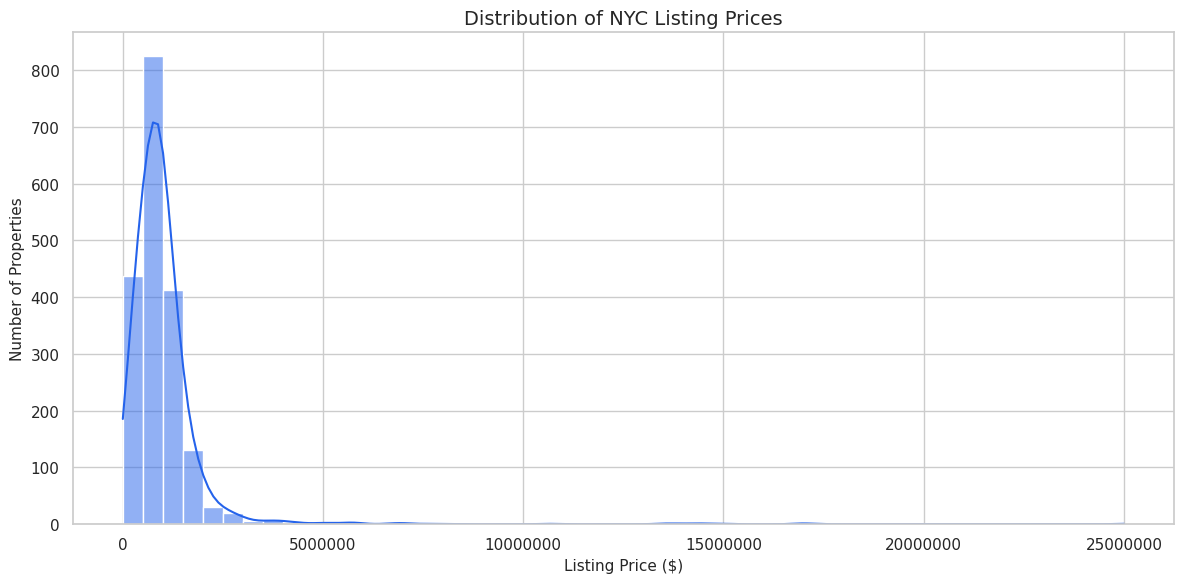

In [12]:
# Plot the full listing-price distribution, including high-value properties.
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="listing_price",
    bins=50,
    kde=True,
    color="#2563EB",
)

# Add clear labels and formatting for a portfolio-ready chart.
plt.title("Distribution of NYC Listing Prices")
plt.xlabel("Listing Price ($)")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()


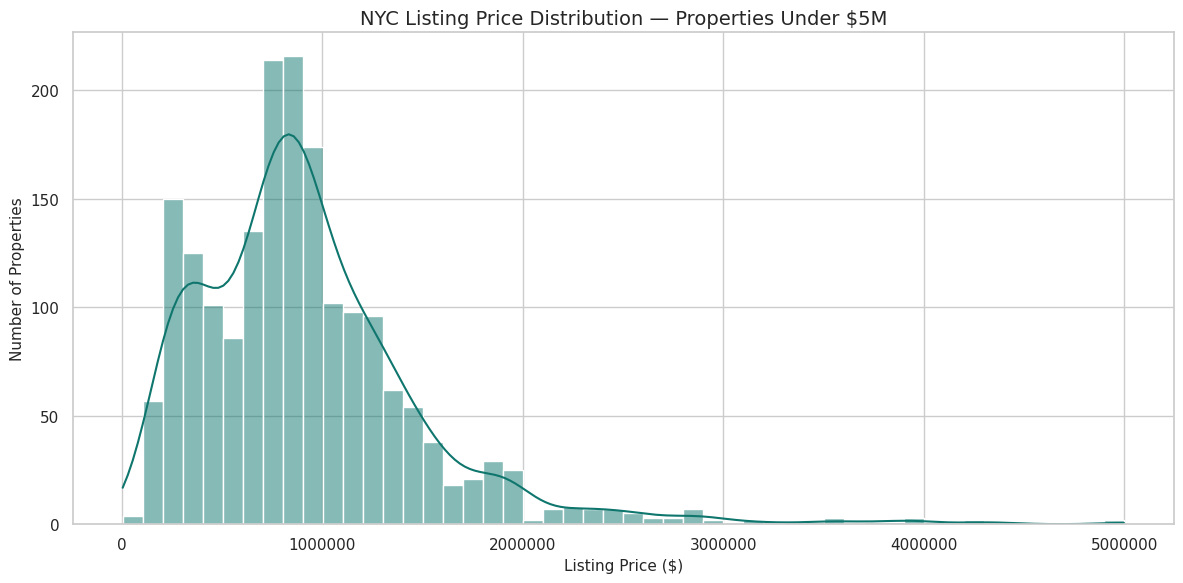

Properties above $5M excluded from zoomed visualization: 18


In [13]:
# Create a visualization-only subset to make the main price distribution easier to see.
# This does not modify or delete observations from the original DataFrame.
price_zoom_df = df.loc[df["listing_price"] <= 5_000_000].copy()

# Plot the distribution of properties priced at or below $5 million.
plt.figure(figsize=(12, 6))

sns.histplot(
    data=price_zoom_df,
    x="listing_price",
    bins=50,
    kde=True,
    color="#0F766E",
)

plt.title("NYC Listing Price Distribution — Properties Under $5M")
plt.xlabel("Listing Price ($)")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

# Report how many observations are outside the visualization range.
excluded_count = len(df) - len(price_zoom_df)
print(f"Properties above $5M excluded from zoomed visualization: {excluded_count:,}")


## 6. Boxplot — Listing Price by Property Type

A boxplot compares the price distribution across property types.

Each box shows the median and interquartile range, while individual points beyond the whiskers represent potential outliers.

This helps answer:

- Which property types have higher typical prices?
- Which property types have greater price variability?
- Which property types contain potential luxury outliers?


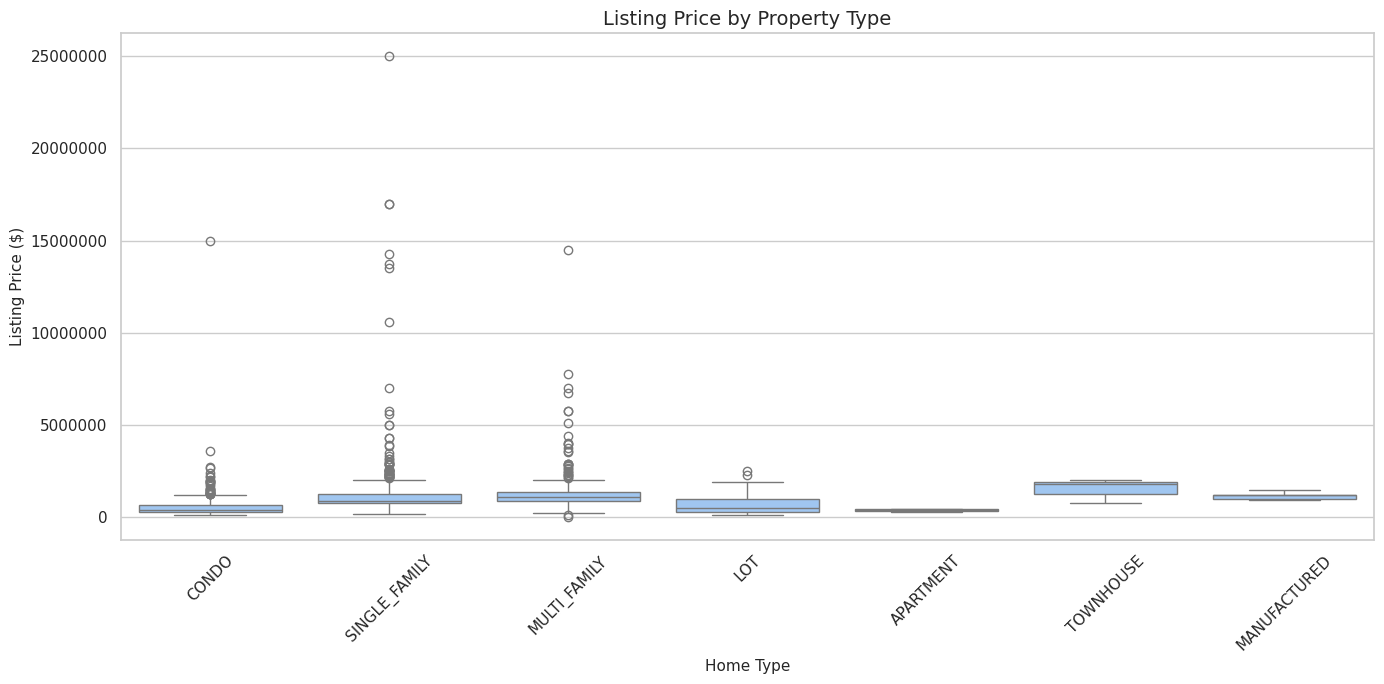

In [14]:
# Plot listing-price distributions for each property type.
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="home_type",
    y="listing_price",
    color="#93C5FD",
)

plt.title("Listing Price by Property Type")
plt.xlabel("Home Type")
plt.ylabel("Listing Price ($)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()


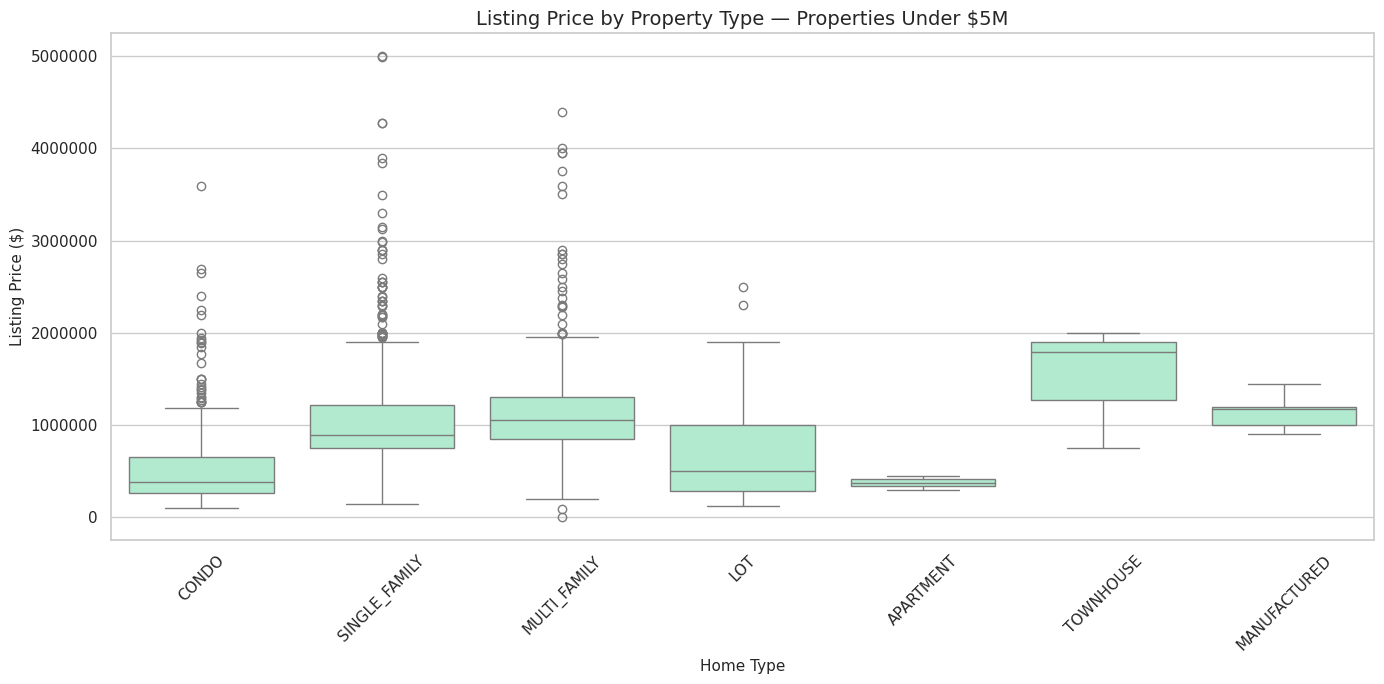

In [15]:
# Create a visualization-only dataset capped at $5 million to make differences
# among the majority of properties easier to compare.
boxplot_zoom_df = df.loc[df["listing_price"] <= 5_000_000].copy()

# Plot the price distributions without allowing a few luxury properties
# to dominate the visual scale.
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=boxplot_zoom_df,
    x="home_type",
    y="listing_price",
    color="#A7F3D0",
)

plt.title("Listing Price by Property Type — Properties Under $5M")
plt.xlabel("Home Type")
plt.ylabel("Listing Price ($)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()


## 7. Price Summary by Property Type

The chart is supported with numerical summaries so that property types can be compared using both average and median prices.

The median is especially useful when a category contains luxury outliers.


In [16]:
# Calculate average price, median price, and listing count for each home type.
home_type_price = (
    df.groupby("home_type", dropna=False)["listing_price"]
    .agg(
        average_price="mean",
        median_price="median",
        listing_count="count",
    )
    .sort_values("median_price", ascending=False)
)

# Display the summary table.
home_type_price


,average_price,median_price,listing_count
home_type,,,
TOWNHOUSE,1.515000e+06,1795000.0,3
MANUFACTURED,1.144580e+06,1175000.0,5
MULTI_FAMILY,1.217053e+06,1062500.0,610
SINGLE_FAMILY,1.239297e+06,890000.0,703
LOT,7.304382e+05,499999.0,34
CONDO,5.358196e+05,385000.0,535
APARTMENT,3.725000e+05,372500.0,2


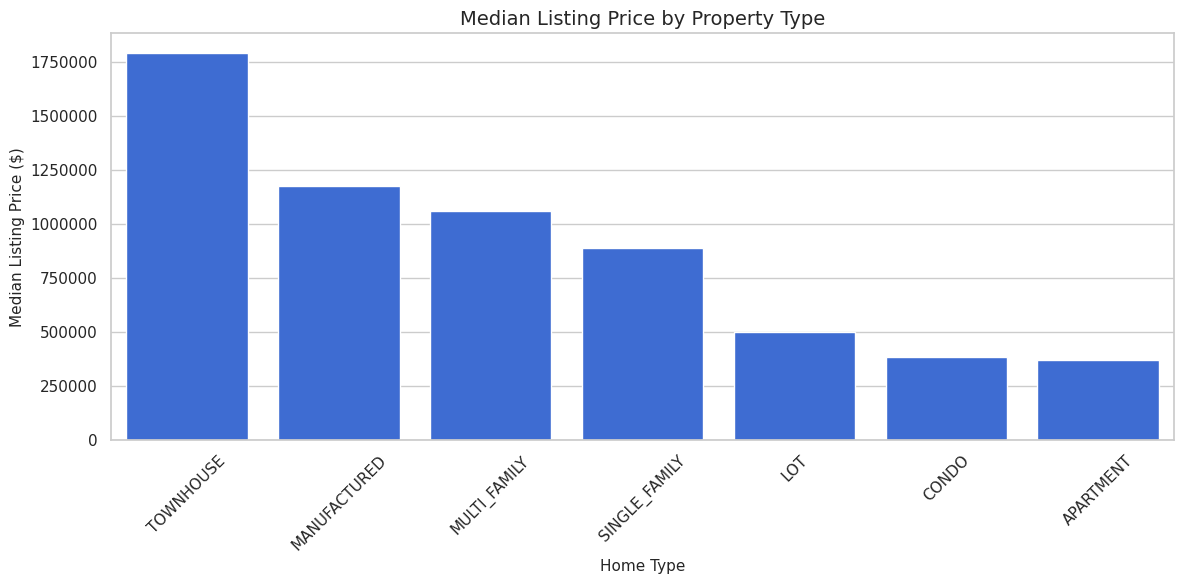

In [17]:
# Visualize median listing price by property type.
plot_df = home_type_price.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="home_type",
    y="median_price",
    color="#2563EB",
)

plt.title("Median Listing Price by Property Type")
plt.xlabel("Home Type")
plt.ylabel("Median Listing Price ($)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()


In [18]:
# Identify the property type with the highest median listing price.
highest_median_type = home_type_price["median_price"].idxmax()
highest_median_value = home_type_price["median_price"].max()

# Display a data-driven observation rather than hard-coding a conclusion.
print(
    f"Highest median listing price: {highest_median_type} "
    f"(${highest_median_value:,.0f})"
)


Highest median listing price: TOWNHOUSE ($1,795,000)


### EDA Questions — Price Distribution

Use the tables and charts above to answer:

1. Which property type has the highest median listing price?
2. Which property type shows the widest price spread?
3. Are there potential luxury outliers?
4. Do multi-family properties show a different price pattern from single-family properties?

These observations should be based on the actual outputs above rather than assumptions.


# Analysis 2 — Property Size Analysis

## 8. Living Area vs. Listing Price

### Objective

The next analysis examines whether larger properties tend to have higher listing prices.

**Hypothesis:** Properties with larger `living_area` generally have higher `listing_price`.

Property size is only one factor, however. Location, property type, condition, neighborhood, and other characteristics can also influence price.


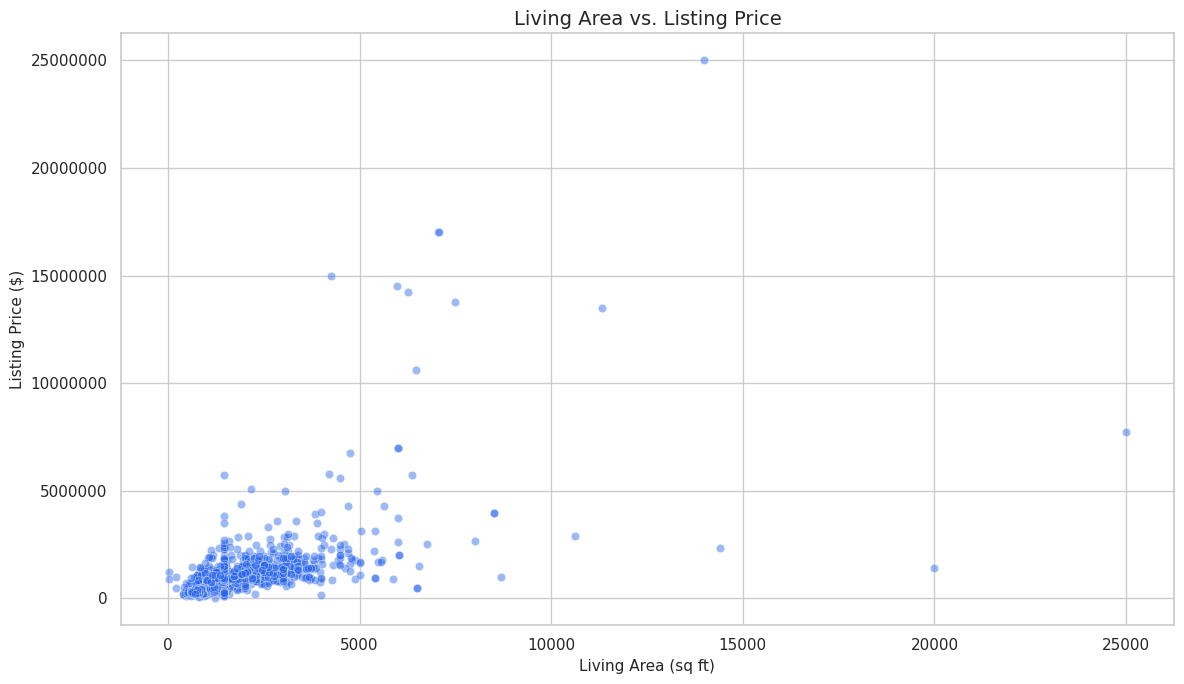

In [19]:
# Keep only records with valid values for the two variables being compared.
size_price_df = (
    df[["living_area", "listing_price"]]
    .dropna()
    .loc[lambda data: data["living_area"] > 0]
    .copy()
)

# Plot the relationship between living area and listing price.
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=size_price_df,
    x="living_area",
    y="listing_price",
    alpha=0.45,
    color="#2563EB",
)

plt.title("Living Area vs. Listing Price")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Listing Price ($)")
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()


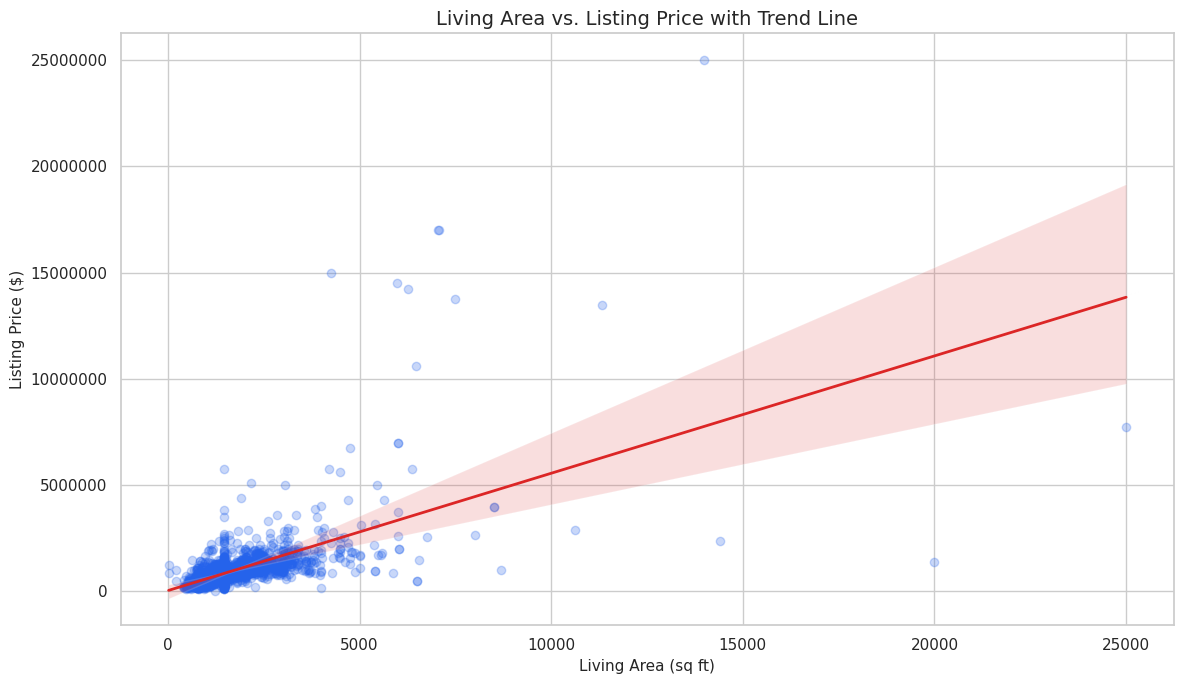

In [20]:
# Add a linear trend line to make the overall direction of the relationship easier to see.
plt.figure(figsize=(12, 7))

sns.regplot(
    data=size_price_df,
    x="living_area",
    y="listing_price",
    scatter_kws={"alpha": 0.25, "color": "#2563EB"},
    line_kws={"color": "#DC2626", "linewidth": 2},
)

plt.title("Living Area vs. Listing Price with Trend Line")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Listing Price ($)")
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()


In [21]:
# Calculate the Pearson correlation between living area and listing price.
size_price_correlation = (
    size_price_df["living_area"]
    .corr(size_price_df["listing_price"])
)

print(f"Pearson correlation: {size_price_correlation:.3f}")


Pearson correlation: 0.588


### Interpretation

A positive correlation indicates that larger properties tend to be associated with higher listing prices in this dataset.

However:

> **Correlation does not imply causation.**

The relationship may also reflect location, property type, neighborhood characteristics, and other factors. This is why `living_area` should be considered together with other predictive features during modeling.


## 9. Inspect Potential Size Outliers

Extremely large properties can strongly affect the scatter plot and correlation.

Rather than automatically deleting them, inspect the largest observations to determine whether they appear to represent legitimate large or multi-family properties.


In [22]:
# Display descriptive statistics for living area.
df["living_area"].describe()


,living_area
count,1892.000000
mean,1787.465116
std,1327.864684
min,20.000000
25%,1077.750000
50%,1467.000000
75%,2100.000000
max,25000.000000


In [23]:
# Inspect the 20 properties with the largest reported living areas.
largest_properties = (
    df[
        ["address", "living_area", "listing_price", "home_type"]
    ]
    .sort_values("living_area", ascending=False)
    .head(20)
)

largest_properties


,address,living_area,listing_price,home_type
1428,"223 Beach 101st St Unit 3C, Rockaway Park, NY ...",25000.0,7750000.0,MULTI_FAMILY
1433,"405 Beach 146th St, Far Rockaway, NY 11694",20000.0,1395000.0,SINGLE_FAMILY
647,"768 Linden Blvd, Brooklyn, NY 11203",14400.0,2350000.0,SINGLE_FAMILY
11,"220 77th St, Brooklyn, NY 11209",14000.0,25000000.0,SINGLE_FAMILY
15,"215 Exeter St, Brooklyn, NY 11235",11314.0,13500000.0,SINGLE_FAMILY
729,"2759 Whitman Dr, Brooklyn, NY 11234",10617.0,2899000.0,SINGLE_FAMILY
65,"519 8th Ave, Brooklyn, NY 11215",8700.0,1000000.0,SINGLE_FAMILY
1726,"34-46 10th Street, Astoria, NY 11106",8520.0,3950000.0,MULTI_FAMILY
1728,"3448 10th St, Astoria, NY 11106",8520.0,3950000.0,MULTI_FAMILY
1724,"35-54 10th St, Astoria, NY 11106",8025.0,2650000.0,MULTI_FAMILY


# Analysis 3 — Location Analysis

## 10. Geographic Distribution

The `latitude` and `longitude` fields allow us to examine where the properties in the dataset are located.

This analysis uses:

- **Plotly** for interactive property maps
- **Folium** for property-density and price-weighted heatmaps

The goal is to understand geographic concentration and identify areas where higher-priced listings appear more frequently.


In [24]:
# Summarize the geographic coordinate ranges in the dataset.
df[["latitude", "longitude"]].describe()


,latitude,longitude
count,1892.000000,1892.000000
mean,40.655924,-73.864046
std,0.058830,0.080838
min,40.556900,-74.035660
25%,40.608998,-73.926327
50%,40.644665,-73.894705
75%,40.682123,-73.796970
max,40.799720,-73.700676


In [25]:
# Check whether any properties are missing latitude or longitude values.
coordinate_missing = df[["latitude", "longitude"]].isna().sum()

coordinate_missing


,0
latitude,0
longitude,0


In [26]:
# Create a map-specific DataFrame containing only the fields needed for visualization.
map_df = (
    df[
        [
            "address",
            "latitude",
            "longitude",
            "listing_price",
            "home_type",
        ]
    ]
    .dropna(subset=["latitude", "longitude", "listing_price"])
    .copy()
)

# Display the first few map records for validation.
map_df.head()


,address,latitude,longitude,listing_price,home_type
0,"572 Louisiana Avenue #1, Brooklyn, NY 11239",40.647620,-73.886810,250000.0,CONDO
1,"2183 Ocean Ave #4A, Brooklyn, NY 11229",40.608430,-73.952736,485000.0,CONDO
2,"8885 15th Ave, Brooklyn, NY 11228",40.605550,-74.015200,1299000.0,SINGLE_FAMILY
3,"300 Milford St, Brooklyn, NY 11208",40.671783,-73.876625,595000.0,SINGLE_FAMILY
4,"2711 Avenue X Unit F2, Brooklyn, NY 11235",40.704254,-73.966420,345000.0,MULTI_FAMILY


## 11. Interactive NYC Property Map

Each point represents one property.

The point color identifies the property type, while hovering over a point shows the address and listing price.


In [27]:
# Use Plotly's MapLibre-based map when available.
# The fallback keeps the notebook compatible with older Plotly versions.
if hasattr(px, "scatter_map"):
    fig = px.scatter_map(
        map_df,
        lat="latitude",
        lon="longitude",
        color="home_type",
        hover_name="address",
        hover_data={
            "listing_price": ":$,.0f",
            "home_type": True,
            "latitude": False,
            "longitude": False,
        },
        zoom=9,
        height=700,
        title="NYC Property Locations by Home Type",
    )
else:
    fig = px.scatter_mapbox(
        map_df,
        lat="latitude",
        lon="longitude",
        color="home_type",
        hover_name="address",
        hover_data={
            "listing_price": ":$,.0f",
            "home_type": True,
        },
        zoom=9,
        height=700,
        mapbox_style="open-street-map",
        title="NYC Property Locations by Home Type",
    )

# Render the interactive map.
fig.show()


## 12. Interactive Price Map

The next map colors properties by `listing_price`.

This makes it easier to visually identify areas where higher-priced listings are concentrated.

> This is a **price map**, not a statistical spatial interpolation. A high-value point represents an expensive listing at that location; it does not mean the entire surrounding neighborhood has the same price.


In [28]:
# Plot properties using listing price as the continuous color scale.
if hasattr(px, "scatter_map"):
    fig = px.scatter_map(
        map_df,
        lat="latitude",
        lon="longitude",
        color="listing_price",
        hover_name="address",
        hover_data={
            "listing_price": ":$,.0f",
            "home_type": True,
            "latitude": False,
            "longitude": False,
        },
        color_continuous_scale="Turbo",
        zoom=9,
        height=700,
        title="NYC Property Prices by Location",
    )
else:
    fig = px.scatter_mapbox(
        map_df,
        lat="latitude",
        lon="longitude",
        color="listing_price",
        hover_name="address",
        hover_data={
            "listing_price": ":$,.0f",
            "home_type": True,
        },
        color_continuous_scale="Turbo",
        zoom=9,
        height=700,
        mapbox_style="open-street-map",
        title="NYC Property Prices by Location",
    )

# Render the interactive price map.
fig.show()


## 13. Property Density Heatmap — Folium

A density heatmap shows where the dataset contains the highest concentration of listings.

This answers a different question from the Plotly price map:

- **Plotly price map:** Where are expensive properties located?
- **Folium density heatmap:** Where are listings concentrated?


In [29]:
# Convert latitude and longitude into the coordinate format required by Folium.
heat_data = (
    map_df[["latitude", "longitude"]]
    .values
    .tolist()
)

# Create a base map centered approximately on NYC.
nyc_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=10,
    tiles="CartoDB positron",
)

# Add a density heatmap based on the number of listings.
HeatMap(
    heat_data,
    radius=10,
    blur=15,
    min_opacity=0.3,
).add_to(nyc_map)

# Display the interactive map.
nyc_map


## 14. Price-Weighted Heatmap

A price-weighted heatmap gives more weight to locations containing higher-priced properties.

Because a raw $25M listing could dominate the heatmap, the price weight is transformed using `log1p`. This reduces the influence of extreme values while preserving the ordering of prices.

This visualization is exploratory and should not be interpreted as a formal neighborhood price estimate.


In [30]:
# Create a copy for the price-weighted heatmap.
price_heatmap_df = map_df.copy()

# Apply a log transformation to reduce the dominance of extremely expensive listings.
price_heatmap_df["price_weight"] = np.log1p(
    price_heatmap_df["listing_price"]
)

# Build the latitude, longitude, and transformed-weight list expected by Folium.
price_heat_data = (
    price_heatmap_df[
        ["latitude", "longitude", "price_weight"]
    ]
    .values
    .tolist()
)

# Create a base NYC map for the price-weighted visualization.
nyc_price_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=10,
    tiles="CartoDB positron",
)

# Add the price-weighted heatmap.
HeatMap(
    price_heat_data,
    radius=15,
    blur=20,
    min_opacity=0.3,
).add_to(nyc_price_map)

# Display the interactive map.
nyc_price_map


# Analysis 4 — Market Analysis

## 15. ZIP Code Market Analysis

ZIP-code-level analysis provides a localized view of the housing market.

For each ZIP code, we calculate:

- **Average listing price**
- **Median listing price**
- **Number of listings**

The listing count is important because a ZIP code with one or two properties can produce a misleading average. Later in this section, we therefore apply a minimum listing threshold for more reliable comparisons.


In [31]:
# Inspect the raw ZIP-code values before standardizing their format.
df["zip_code"].head()


,zip_code
0,11239
1,11229
2,11228
3,11208
4,11235


In [32]:
# Convert ZIP codes to numeric values so values such as '11201.0' become 11201.
# Invalid values are converted to missing values rather than causing the notebook to fail.
df["zip_code"] = pd.to_numeric(
    df["zip_code"],
    errors="coerce",
)

# Convert ZIP codes to pandas' nullable string type.
# Keeping ZIP codes as strings prevents them from being treated as continuous numeric features.
df["zip_code"] = df["zip_code"].astype("Int64").astype("string")

# Report the number of unique ZIP codes after standardization.
print(f"Unique ZIP codes: {df['zip_code'].nunique(dropna=True):,}")


Unique ZIP codes: 95


In [33]:
# Group listings by ZIP code and calculate the requested market statistics.
zip_market = (
    df.dropna(subset=["zip_code", "listing_price"])
    .groupby("zip_code")["listing_price"]
    .agg(
        average_price="mean",
        median_price="median",
        listing_count="count",
    )
    .sort_values("median_price", ascending=False)
)

# Display the ZIP-code market summary.
zip_market.head(20)


,average_price,median_price,listing_count
zip_code,,,
11201,6.194846e+06,4995000.0,13
11238,3.942500e+06,3885000.0,4
11231,5.983333e+06,2750000.0,3
11249,2.462500e+06,2462500.0,2
11109,1.743000e+06,1743000.0,2
11216,1.625000e+06,1625000.0,2
11357,2.037514e+06,1458800.0,21
11361,1.414833e+06,1398000.0,21
11366,1.388000e+06,1388000.0,1


## 16. Top ZIP Codes by Median Listing Price

Median price is a useful measure for comparing ZIP codes because it is less sensitive to a small number of luxury listings than the mean.


In [34]:
# Select the 15 ZIP codes with the highest median listing prices.
top_zip_median = (
    zip_market
    .sort_values("median_price", ascending=False)
    .head(15)
    .reset_index()
)

# Display the top ZIP codes before plotting.
top_zip_median


,zip_code,average_price,median_price,listing_count
0,11201,6.194846e+06,4995000.0,13
1,11238,3.942500e+06,3885000.0,4
2,11231,5.983333e+06,2750000.0,3
3,11249,2.462500e+06,2462500.0,2
4,11109,1.743000e+06,1743000.0,2
5,11216,1.625000e+06,1625000.0,2
6,11357,2.037514e+06,1458800.0,21
7,11361,1.414833e+06,1398000.0,21
8,11366,1.388000e+06,1388000.0,1
9,11101,1.499778e+06,1377500.0,40


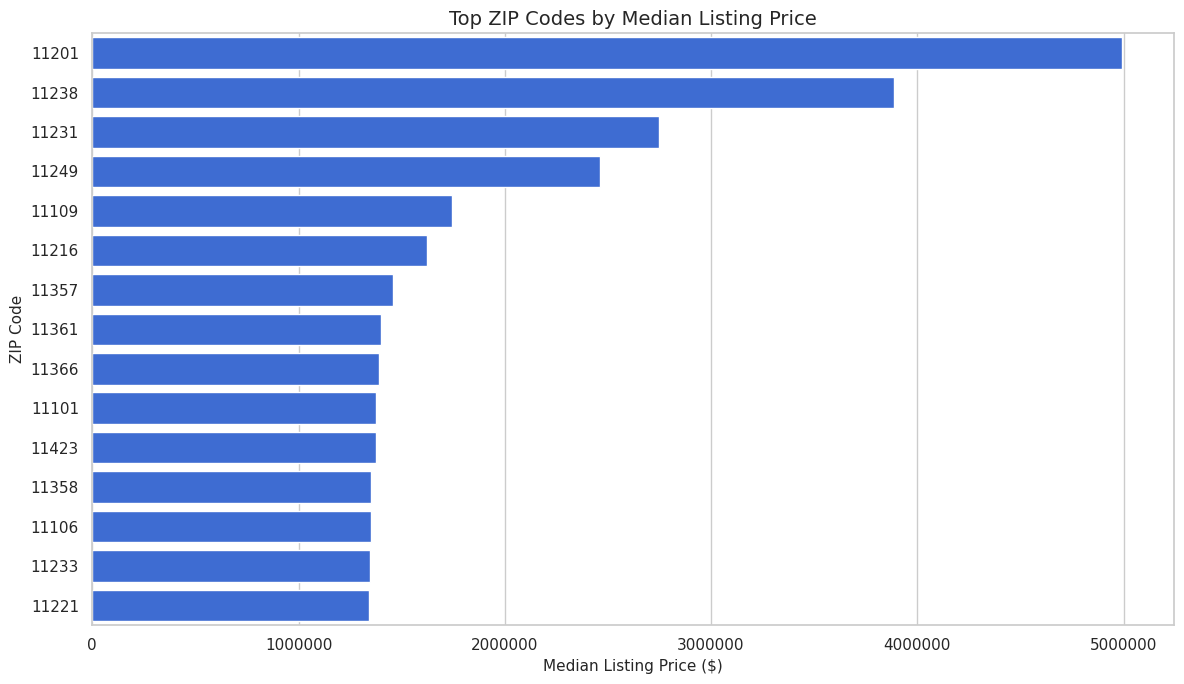

In [35]:
# Visualize the top ZIP codes by median listing price.
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_zip_median,
    x="median_price",
    y="zip_code",
    color="#2563EB",
)

plt.title("Top ZIP Codes by Median Listing Price")
plt.xlabel("Median Listing Price ($)")
plt.ylabel("ZIP Code")
plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()


## 17. Top ZIP Codes by Average Listing Price

Average price can be strongly influenced by luxury properties. Comparing average price with median price helps identify ZIP codes where a small number of expensive listings may be pulling the average upward.


In [36]:
# Select the 15 ZIP codes with the highest average listing prices.
top_zip_average = (
    zip_market
    .sort_values("average_price", ascending=False)
    .head(15)
    .reset_index()
)

# Display the top ZIP codes by average price.
top_zip_average


,zip_code,average_price,median_price,listing_count
0,11201,6.194846e+06,4995000.0,13
1,11231,5.983333e+06,2750000.0,3
2,11238,3.942500e+06,3885000.0,4
3,11209,3.060091e+06,699000.0,11
4,11249,2.462500e+06,2462500.0,2
5,11357,2.037514e+06,1458800.0,21
6,11106,1.798385e+06,1350000.0,13
7,11109,1.743000e+06,1743000.0,2
8,11216,1.625000e+06,1625000.0,2
9,11217,1.573333e+06,1185000.0,6


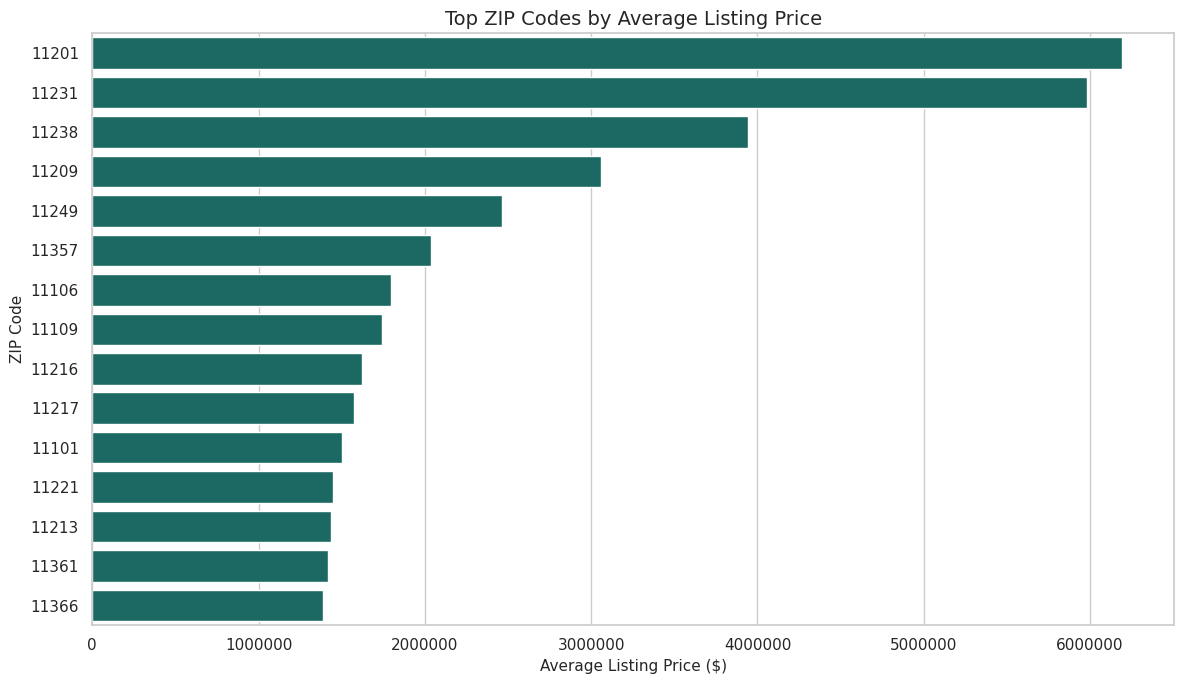

In [37]:
# Visualize the top ZIP codes by average listing price.
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_zip_average,
    x="average_price",
    y="zip_code",
    color="#0F766E",
)

plt.title("Top ZIP Codes by Average Listing Price")
plt.xlabel("Average Listing Price ($)")
plt.ylabel("ZIP Code")
plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()


## 18. ZIP Codes with the Most Listings

Listing count provides context for the price comparisons.

A ZIP code with a high average price but very few observations should be interpreted more cautiously than a ZIP code with many listings.


In [38]:
# Identify the ZIP codes with the largest number of listings.
top_zip_count = (
    zip_market
    .sort_values("listing_count", ascending=False)
    .head(15)
    .reset_index()
)

# Display the highest-volume ZIP codes.
top_zip_count


,zip_code,average_price,median_price,listing_count
0,11234,1.006828e+06,899000.0,319
1,11236,1.002630e+06,879499.5,164
2,11414,7.430890e+05,549000.0,123
3,11229,5.264967e+05,350000.0,113
4,11203,9.679026e+05,849999.0,73
5,11694,1.317086e+06,697000.0,72
6,11235,8.558842e+05,527000.0,70
7,11691,9.429028e+05,800000.0,65
8,11413,1.022432e+06,1000000.0,55
9,11422,9.501567e+05,879000.0,44


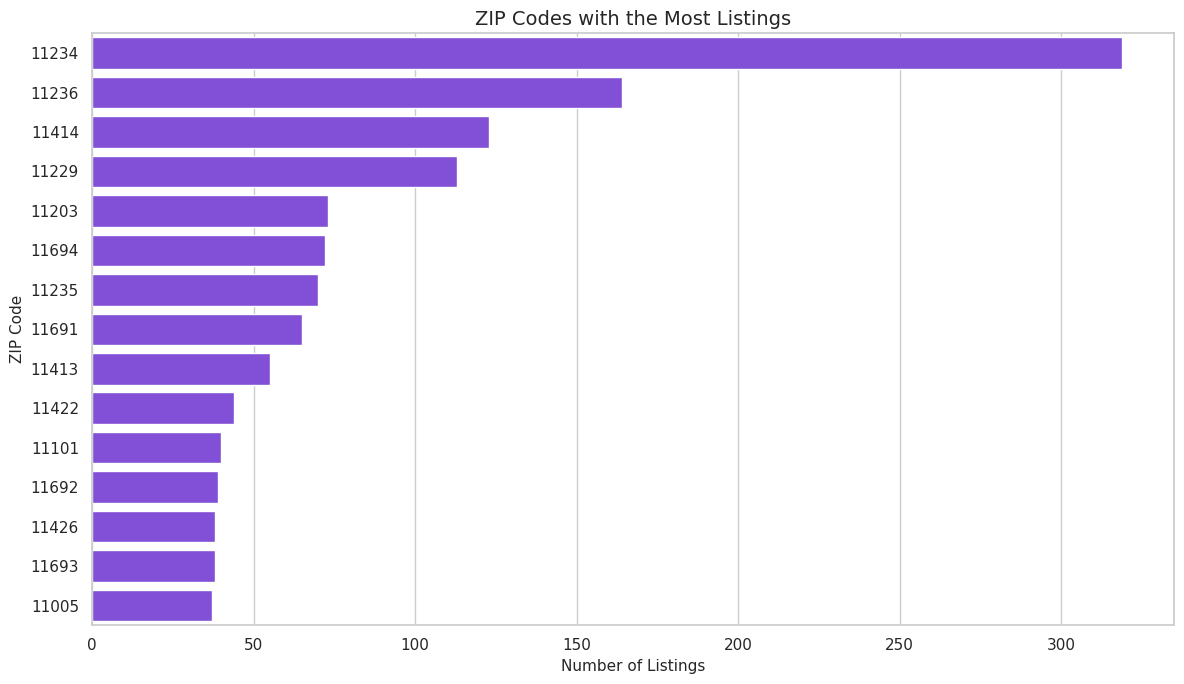

In [39]:
# Visualize the ZIP codes with the most listings.
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_zip_count,
    x="listing_count",
    y="zip_code",
    color="#7C3AED",
)

plt.title("ZIP Codes with the Most Listings")
plt.xlabel("Number of Listings")
plt.ylabel("ZIP Code")

plt.tight_layout()
plt.show()


## 19. Reliable ZIP-Code Comparisons

To avoid over-interpreting ZIP codes with only a handful of listings, apply a minimum threshold.

For this exploratory analysis, ZIP codes with **at least 10 listings** are treated as higher-confidence groups.

This threshold is a reporting choice, not a universal statistical rule.


In [40]:
# Keep ZIP codes with at least 10 listings for more stable market comparisons.
MIN_LISTINGS = 10

zip_market_reliable = zip_market.loc[
    zip_market["listing_count"] >= MIN_LISTINGS
].copy()

# Display the highest-median-price ZIP codes that meet the minimum sample-size threshold.
zip_market_reliable.sort_values(
    "median_price",
    ascending=False,
).head(15)


,average_price,median_price,listing_count
zip_code,,,
11201,6.194846e+06,4995000.0,13
11357,2.037514e+06,1458800.0,21
11361,1.414833e+06,1398000.0,21
11101,1.499778e+06,1377500.0,40
11106,1.798385e+06,1350000.0,13
11233,1.352182e+06,1349000.0,11
11228,1.250368e+06,1280000.0,17
11420,1.104327e+06,1094499.5,26
11434,1.048033e+06,1049000.0,27


## 20. Average vs. Median Price

The difference between average and median price can highlight price skew.

If the average is substantially higher than the median, a ZIP code may contain a relatively small number of very expensive properties.

This does not automatically mean the data is incorrect; it may reflect genuine market segmentation.


In [41]:
# Compare average and median prices for ZIP codes with at least 10 listings.
zip_price_comparison = zip_market_reliable.copy()

# Calculate how much the average price exceeds the median price.
zip_price_comparison["average_minus_median"] = (
    zip_price_comparison["average_price"]
    - zip_price_comparison["median_price"]
)

# Display ZIP codes with the largest average-minus-median differences.
zip_price_comparison.sort_values(
    "average_minus_median",
    ascending=False,
).head(15)


,average_price,median_price,listing_count,average_minus_median
zip_code,,,,
11209,3.060091e+06,699000.0,11,2.361091e+06
11201,6.194846e+06,4995000.0,13,1.199846e+06
11694,1.317086e+06,697000.0,72,6.200858e+05
11357,2.037514e+06,1458800.0,21,5.787143e+05
11106,1.798385e+06,1350000.0,13,4.483845e+05
11375,1.077187e+06,711500.0,16,3.656874e+05
11235,8.558842e+05,527000.0,70,3.288842e+05
11362,1.002085e+06,782000.0,27,2.200851e+05
11414,7.430890e+05,549000.0,123,1.940890e+05


# Optional EDA — Price per Square Foot

## 21. Price per Square Foot

Price per square foot provides another useful way to compare properties with different sizes.

**Formula:**

\[
\text{Price per Sq Ft} = \frac{\text{Listing Price}}{\text{Living Area}}
\]

This metric is useful for EDA and market comparison, but it should **not** be used as a model feature when `listing_price` is the target because it is directly calculated from the target and would create data leakage.


In [42]:
# Create an EDA-only copy so the original cleaned dataset is not modified.
eda_ppsf_df = df.copy()

# Replace non-positive living-area values with NaN because division by zero
# or negative square footage would produce invalid price-per-square-foot values.
eda_ppsf_df.loc[
    eda_ppsf_df["living_area"] <= 0,
    "living_area",
] = np.nan

# Calculate price per square foot for exploratory analysis only.
eda_ppsf_df["price_per_sqft_eda"] = (
    eda_ppsf_df["listing_price"]
    / eda_ppsf_df["living_area"]
)

# Display descriptive statistics for the derived metric.
eda_ppsf_df["price_per_sqft_eda"].describe()


,price_per_sqft_eda
count,1892.000000
mean,631.877910
std,1719.581332
min,2.907916
25%,401.566464
50%,519.419306
75%,674.421371
max,59523.809524


In [43]:
# Calculate ZIP-code-level price-per-square-foot statistics.
zip_ppsf = (
    eda_ppsf_df
    .dropna(subset=["zip_code", "price_per_sqft_eda"])
    .groupby("zip_code")["price_per_sqft_eda"]
    .agg(
        average_ppsf="mean",
        median_ppsf="median",
        listing_count="count",
    )
    .sort_values("median_ppsf", ascending=False)
)

# Keep only ZIP codes with at least 10 observations for a more reliable comparison.
zip_ppsf_reliable = zip_ppsf.loc[
    zip_ppsf["listing_count"] >= MIN_LISTINGS
]

# Display the ZIP codes with the highest median price per square foot.
zip_ppsf_reliable.head(15)


,average_ppsf,median_ppsf,listing_count
zip_code,,,
11201,1703.393526,1637.164041,13
11101,1314.514338,1342.846203,40
11228,805.328230,837.438424,17
11357,765.812261,763.636364,21
11233,647.437982,747.916667,11
11361,775.348081,739.506173,21
11420,660.159031,694.829307,26
11214,618.832081,678.030303,25
11426,597.936136,624.093048,38


# 22. EDA Summary and Modeling Implications

This EDA established the major patterns that should guide the next phase of the project.

### Price Distribution
- Listing prices should be evaluated using both mean and median because luxury properties can create strong right-skew.
- Property-type comparisons reveal differences in typical price and price variability.
- Potential outliers should be investigated rather than automatically removed.

### Property Size
- The relationship between `living_area` and `listing_price` can be assessed visually and with correlation.
- Size is useful, but it does not explain price by itself.
- Extremely large properties should be inspected for legitimate multi-family or luxury listings.

### Location
- Latitude and longitude reveal the geographic distribution of the dataset.
- Interactive maps help identify areas where listings and higher prices are concentrated.
- A map is useful for exploration, but it should not be treated as a formal statistical estimate of neighborhood prices.

### ZIP-Code Market
- Average and median prices provide complementary views of local markets.
- Listing count provides important context for the reliability of ZIP-code comparisons.
- A minimum listing threshold reduces the risk of over-interpreting ZIP codes with very few observations.

### Feature Engineering / Modeling Implications

The EDA suggests that the next phase should consider features such as:

- `living_area`
- `bedrooms`
- `bathrooms`
- `latitude`
- `longitude`
- `zip_code`
- `home_type`
- `days_on_zillow`
- `rent_estimate`
- `zestimate`
- `tax_assessed_value`

Target-derived variables such as `price_per_sqft`, `price_vs_zestimate`, and other price-ratio features should be kept for **EDA only** and excluded from model training when `listing_price` is the prediction target.

---

## Next Step

**Phase 5 — Feature Engineering**

The next phase will transform the EDA findings into model-ready features while addressing categorical variables, geographic information, missing-value indicators, skewed variables, and potential data leakage.
